In [ ]:
import pandas as pd
import numpy as np


In [ ]:
stores_df = pd.read_csv('/content/stores.csv')
print('stores_df:')
display(stores_df.head())

suppliers_df = pd.read_csv('/content/suppliers.csv')
print('\nsuppliers_df:')
display(suppliers_df.head())

payments_df = pd.read_csv('/content/payments.csv')
print('\npayments_df:')
display(payments_df.head())

employees_df = pd.read_csv('/content/employees.csv')
print('\nemployees_df:')
display(employees_df.head())

customers_df = pd.read_csv('/content/customers.csv')
print('\ncustomers_df:')
display(customers_df.head())

categories_df = pd.read_csv('/content/categories.csv')
print('\ncategories_df:')
display(categories_df.head())

products_df = pd.read_csv('/content/products.csv')
print('\nproducts_df:')
display(products_df.head())

returns_df = pd.read_csv('/content/returns.csv')
print('\nreturns_df:')
display(returns_df.head())

order_items_df = pd.read_csv('/content/order_items.csv')
print('\norder_items_df:')
display(order_items_df.head())

shipments_df = pd.read_csv('/content/shipments.csv')
print('\nshipments_df:')
display(shipments_df.head())

orders_df = pd.read_csv('/content/orders.csv')
print('\norders_df:')
display(orders_df.head())

promotions_df = pd.read_csv('/content/promotions.csv')
print('\npromotions_df:')
display(promotions_df.head())

stores_df:


,store_id,city
0,1,Pune
1,2,Pune
2,3,Delhi
3,4,Mumbai
4,5,Mumbai



suppliers_df:


,supplier_id,country
0,1,India
1,2,India
2,3,India
3,4,USA
4,5,China



payments_df:


...

,shipment_id,order_id,status
0,1,1,delivered
1,2,2,shipped
2,3,3,late
3,4,4,late
4,5,5,late



orders_df:


,order_id,customer_id,store_id,order_date,promotion_id
0,1,45308,33,2021-08-26,24
1,2,10070,81,2022-03-19,3
2,3,43308,17,2021-01-21,25
3,4,47997,85,2021-01-16,48
4,5,36546,81,2022-09-14,33



promotions_df:


,promotion_id,discount
0,1,6
1,2,24
2,3,27
3,4,14
4,5,7


In [ ]:
merged_df = order_items_df.copy()

print("Merging tables...")

products_df_renamed = products_df.rename(columns={'price': 'base_product_price'})
merged_df = pd.merge(merged_df, products_df_renamed, on='product_id', how='left')
print("  - Merged products_df")

#. Merge with categories_df on 'category_id'
merged_df = pd.merge(merged_df, categories_df, on='category_id', how='left')
print("  - Merged categories_df")


merged_df = pd.merge(merged_df, suppliers_df, on='supplier_id', how='left')
print("  - Merged suppliers_df")


merged_df = pd.merge(merged_df, orders_df, on='order_id', how='left')
print("  - Merged orders_df")


customers_df_renamed = customers_df.rename(columns={'city': 'customer_city'})
merged_df = pd.merge(merged_df, customers_df_renamed, on='customer_id', how='left')
print("  - Merged customers_df")

stores_df_renamed = stores_df.rename(columns={'city': 'store_city'})
merged_df = pd.merge(merged_df, stores_df_renamed, on='store_id', how='left')
print("  - Merged stores_df")

merged_df = pd.merge(merged_df, employees_df, on='store_id', how='left')
print("  - Merged employees_df (potential row duplication for multiple employees per store)")

merged_df = pd.merge(merged_df, promotions_df, on='promotion_id', how='left')
print("  - Merged promotions_df")

merged_df = pd.merge(merged_df, payments_df, on='order_id', how='left')
print("  - Merged payments_df")

merged_df = pd.merge(merged_df, shipments_df, on='order_id', how='left')
print("  - Merged shipments_df")

merged_df = pd.merge(merged_df, returns_df, on='order_item_id', how='left')
print("  - Merged returns_df")

print("\nFinal Merged DataFrame (first 5 rows):")
display(merged_df.head())
print(f"Shape of the final merged DataFrame: {merged_df.shape}")

Merging tables...
  - Merged products_df
  - Merged categories_df
  - Merged suppliers_df
  - Merged orders_df
  - Merged customers_df
  - Merged stores_df
  - Merged employees_df (potential row duplication for multiple employees per store)
  - Merged promotions_df
  - Merged payments_df
  - Merged shipments_df
  - Merged returns_df

Final Merged DataFrame (first 5 rows):


,order_item_id,order_id,product_id,qty,price,category_id,supplier_id,base_product_price,category_name,country,...,store_city,employee_id,salary,discount,payment_id,amount,shipment_id,status,return_id,refund
0,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,91,35914,38,145042,2609,145042,late,NaN,NaN
1,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,126,32787,38,145042,2609,145042,late,NaN,NaN
2,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,207,49073,38,145042,2609,145042,late,NaN,NaN
3,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,271,71120,38,145042,2609,145042,late,NaN,NaN
4,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,301,45533,38,145042,2609,145042,late,NaN,NaN


Shape of the final merged DataFrame: (6012009, 26)


In [ ]:
data=merged_df
data

,order_item_id,order_id,product_id,qty,price,category_id,supplier_id,base_product_price,category_name,country,...,store_city,employee_id,salary,discount,payment_id,amount,shipment_id,status,return_id,refund
0,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,91,35914,38,145042,2609,145042,late,NaN,NaN
1,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,126,32787,38,145042,2609,145042,late,NaN,NaN
2,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,207,49073,38,145042,2609,145042,late,NaN,NaN
3,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,271,71120,38,145042,2609,145042,late,NaN,NaN
4,1,145042,472,3,176,13,189,4048,Cat_13,USA,...,Bangalore,301,45533,38,145042,2609,145042,late,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6012004,600000,298854,4441,3,3074,28,3,1729,Cat_28,India,...,Bangalore,886,21839,39,298854,9844,298854,delivered,NaN,NaN
6012005,600000,298854,4441,3,3074,28,3,1729,Cat_28,India,...,Bangalore,898,72746,39,298854,9844,298854,delivered,NaN,NaN
6012006,600000,298854,4441,3,3074,28,3,1729,Cat_28,India,...,Bangalore,900,36817,39,298854,9844,298854,delivered,NaN,NaN
6012007,600000,298854,4441,3,3074,28,3,1729,Cat_28,India,...,Bangalore,921,22748,39,298854,9844,298854,delivered,NaN,NaN


In [ ]:
print(f"Shape of DataFrame before removing nulls: {data.shape}")
rows_before_drop = data.shape[0]

# Remove rows with any null values
data_cleaned = data.dropna()

rows_after_drop = data_cleaned.shape[0]
num_rows_dropped = rows_before_drop - rows_after_drop

print(f"Shape of DataFrame after removing nulls: {data_cleaned.shape}")
print(f"Number of rows removed: {num_rows_dropped}")
display(data_cleaned.head())

Shape of DataFrame before removing nulls: (6012009, 26)
Shape of DataFrame after removing nulls: (300263, 26)
Number of rows removed: 5711746


,order_item_id,order_id,product_id,qty,price,category_id,supplier_id,base_product_price,category_name,country,...,store_city,employee_id,salary,discount,payment_id,amount,shipment_id,status,return_id,refund
153,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,189,69643,29,85517,10044,85517,late,17776.0,2022.0
154,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,340,77875,29,85517,10044,85517,late,17776.0,2022.0
155,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,514,29275,29,85517,10044,85517,late,17776.0,2022.0
156,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,584,23613,29,85517,10044,85517,late,17776.0,2022.0
157,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,611,31544,29,85517,10044,85517,late,17776.0,2022.0


In [ ]:
print(f"Shape of DataFrame before removing duplicates: {data_cleaned.shape}")
rows_before_dedup = data_cleaned.shape[0]

# Remove duplicate rows
data_deduplicated = data_cleaned.drop_duplicates()

rows_after_dedup = data_deduplicated.shape[0]
num_rows_dropped_dedup = rows_before_dedup - rows_after_dedup

print(f"Shape of DataFrame after removing duplicates: {data_deduplicated.shape}")
print(f"Number of duplicate rows removed: {num_rows_dropped_dedup}")
display(data_deduplicated.head())

Shape of DataFrame before removing duplicates: (300263, 26)
Shape of DataFrame after removing duplicates: (300263, 26)
Number of duplicate rows removed: 0


,order_item_id,order_id,product_id,qty,price,category_id,supplier_id,base_product_price,category_name,country,...,store_city,employee_id,salary,discount,payment_id,amount,shipment_id,status,return_id,refund
153,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,189,69643,29,85517,10044,85517,late,17776.0,2022.0
154,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,340,77875,29,85517,10044,85517,late,17776.0,2022.0
155,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,514,29275,29,85517,10044,85517,late,17776.0,2022.0
156,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,584,23613,29,85517,10044,85517,late,17776.0,2022.0
157,17,85517,8521,4,4522,23,86,4003,Cat_23,USA,...,Bangalore,611,31544,29,85517,10044,85517,late,17776.0,2022.0


### Outlier Detection

We will now check for outliers in the numerical columns of the `data_deduplicated` DataFrame. Outliers can be identified using statistical methods like the Interquartile Range (IQR) or by visualizing data distributions using box plots.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier detection
numerical_cols = data_deduplicated.select_dtypes(include=np.number).columns.tolist()

print(f"Numerical columns identified for outlier checking: {numerical_cols}")

Numerical columns identified for outlier checking: ['order_item_id', 'order_id', 'product_id', 'qty', 'price', 'category_id', 'supplier_id', 'base_product_price', 'customer_id', 'store_id', 'promotion_id', 'employee_id', 'salary', 'discount', 'payment_id', 'amount', 'shipment_id', 'return_id', 'refund']


#### Visualizing Outliers with Box Plots

Let's visualize the distribution of some potentially significant numerical columns using box plots to visually identify outliers. We will focus on columns like `qty`, `price`, `base_product_price`, `salary`, `discount`, and `amount`.

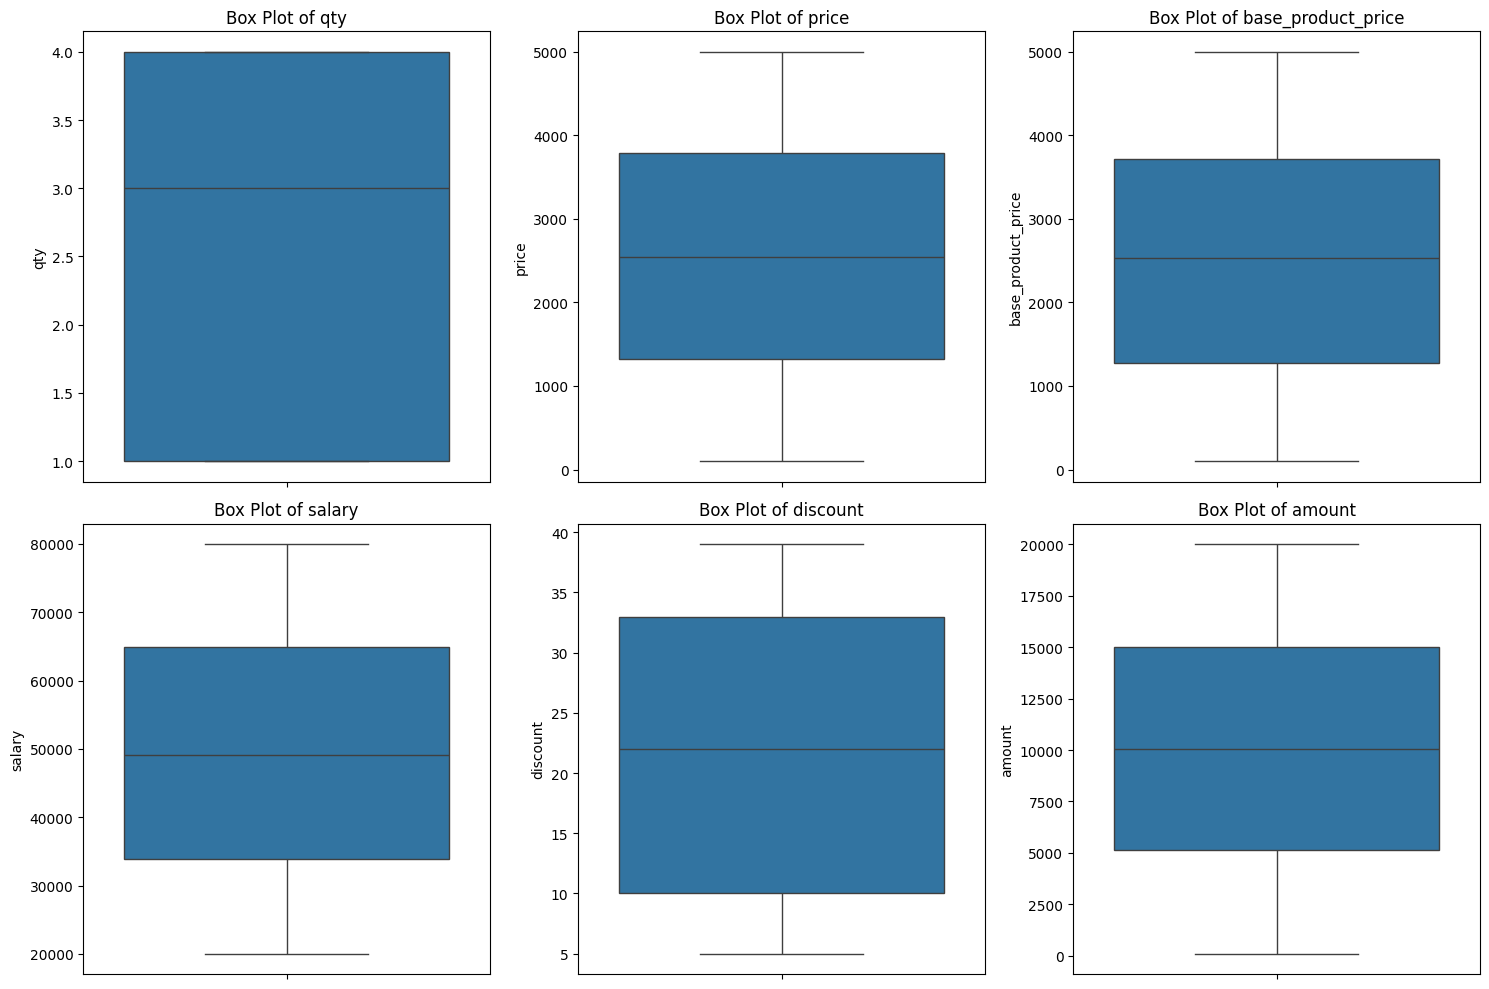

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['qty', 'price', 'base_product_price', 'salary', 'discount', 'amount'], 1):
    if col in numerical_cols:
        plt.subplot(2, 3, i)
        sns.boxplot(y=data_deduplicated[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Statistical Outlier Detection using IQR


In [ ]:
outliers_summary = {}

for col in numerical_cols:
    Q1 = data_deduplicated[col].quantile(0.25)
    Q3 = data_deduplicated[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data_deduplicated[(data_deduplicated[col] < lower_bound) | (data_deduplicated[col] > upper_bound)]

    if not outliers.empty:
        outliers_summary[col] = {
            'num_outliers': len(outliers),
            'percentage': (len(outliers) / len(data_deduplicated)) * 100,
            'min_outlier_value': outliers[col].min(),
            'max_outlier_value': outliers[col].max()
        }

if outliers_summary:
    print("Outliers detected in the following columns (based on IQR method):")
    for col, info in outliers_summary.items():
        print(f"- {col}: {info['num_outliers']} outliers ({info['percentage']:.2f}% of data)")
        print(f"  Range of outliers: [{info['min_outlier_value']}, {info['max_outlier_value']}]")
else:
    print("No significant outliers detected based on the IQR method in numerical columns.")


No significant outliers detected based on the IQR method in numerical columns.


In [ ]:
dat=data_deduplicated

In [ ]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300263 entries, 153 to 6011718
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_item_id       300263 non-null  int64  
 1   order_id            300263 non-null  int64  
 2   product_id          300263 non-null  int64  
 3   qty                 300263 non-null  int64  
 4   price               300263 non-null  int64  
 5   category_id         300263 non-null  int64  
 6   supplier_id         300263 non-null  int64  
 7   base_product_price  300263 non-null  int64  
 8   category_name       300263 non-null  object 
 9   country             300263 non-null  object 
 10  customer_id         300263 non-null  int64  
 11  store_id            300263 non-null  int64  
 12  order_date          300263 non-null  object 
 13  promotion_id        300263 non-null  int64  
 14  customer_city       300263 non-null  object 
 15  signup_date         300263 non-null 

In [ ]:
dat.describe()

,order_item_id,order_id,product_id,qty,price,category_id,supplier_id,base_product_price,customer_id,store_id,promotion_id,employee_id,salary,discount,payment_id,amount,shipment_id,return_id,refund
count,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000,300263.000000
mean,299385.734586,149536.816564,5002.782274,2.498063,2550.023503,15.526692,99.352148,2520.692589,24906.593290,50.007707,25.589640,500.772333,49500.138176,21.837106,149536.816564,10069.243683,149536.816564,14993.859996,2534.152819
std,173080.430887,86466.043820,2889.994062,1.120782,1421.126724,8.568273,58.274200,1412.589634,14484.273419,28.424727,14.405935,288.800743,17367.465034,11.951739,86466.043820,5722.713189,86466.043820,8659.570652,1427.920697
min,17.000000,6.000000,1.000000,1.000000,100.000000,1.000000,1.000000,100.000000,1.000000,1.000000,1.000000,1.000000,20046.000000,5.000000,6.000000,101.000000,6.000000,1.000000,50.000000
25%,149689.000000,74886.500000,2479.000000,1.000000,1319.000000,8.000000,48.000000,1278.000000,12260.000000,25.000000,13.000000,251.000000,33968.000000,10.000000,74886.500000,5157.000000,74886.500000,7495.000000,1304.000000
50%,298603.000000,149595.000000,5017.000000,3.000000,2542.000000,15.000000,98.000000,2526.000000,24903.000000,51.000000,26.000000,500.000000,49095.000000,22.000000,149595.000000,10057.000000,149595.000000,14993.000000,2535.000000
75%,447827.500000,224393.000000,7509.000000,4.000000,3785.000000,23.000000,150.000000,3719.000000,37428.000000,74.000000,38.000000,751.000000,64892.000000,33.000000,224393.000000,14998.000000,224393.000000,22501.000000,3784.000000
max,599973.000000,299925.000000,10000.000000,4.000000,4999.000000,30.000000,200.000000,4999.000000,49998.000000,100.000000,50.000000,1000.000000,79949.000000,39.000000,299925.000000,19999.000000,299925.000000,30000.000000,4999.000000


# Task
The goal is to build a classification model to predict whether an order item will be returned or not. This involves defining a target variable, performing feature engineering and preprocessing, splitting the data, training a classification model, and evaluating its performance. Finally, a summary of the model building process and its performance will be provided.

## Define Target Variable

Create a binary target variable 'is_returned' from the 'return_id' column in the `dat` DataFrame. If 'return_id' is not null, it indicates a returned item (1), otherwise it's a non-returned item (0).


In [ ]:
dat['is_returned'] = dat['return_id'].apply(lambda x: 0 if pd.isna(x) else 1)
print(dat['is_returned'].value_counts())
print(dat.head())

is_returned
1    300263
Name: count, dtype: int64
     order_item_id  order_id  product_id  qty  price  category_id  \
153             17     85517        8521    4   4522           23   
154             17     85517        8521    4   4522           23   
155             17     85517        8521    4   4522           23   
156             17     85517        8521    4   4522           23   
157             17     85517        8521    4   4522           23   

     supplier_id  base_product_price category_name country  ...  employee_id  \
153           86                4003        Cat_23     USA  ...          189   
154           86                4003        Cat_23     USA  ...          340   
155           86                4003        Cat_23     USA  ...          514   
156           86                4003        Cat_23     USA  ...          584   
157           86                4003        Cat_23     USA  ...          611   

     salary discount  payment_id amount shipment_id st

## Feature Engineering and Preprocessing




In [ ]:
print("Missing values before date feature engineering:")
print(dat.isnull().sum()[dat.isnull().sum() > 0])

# Convert date columns to datetime objects
dat['order_date'] = pd.to_datetime(dat['order_date'])
dat['signup_date'] = pd.to_datetime(dat['signup_date'])

# Extract time-based features from 'order_date'
dat['order_year'] = dat['order_date'].dt.year
dat['order_month'] = dat['order_date'].dt.month
dat['order_dayofweek'] = dat['order_date'].dt.dayofweek

# Extract time-based features from 'signup_date'
dat['signup_year'] = dat['signup_date'].dt.year
dat['signup_month'] = dat['signup_date'].dt.month
dat['signup_dayofweek'] = dat['signup_date'].dt.dayofweek

print("\nDataFrame info after date feature engineering:")
dat.info()

Missing values before date feature engineering:
Series([], dtype: int64)

DataFrame info after date feature engineering:
<class 'pandas.core.frame.DataFrame'>
Index: 300263 entries, 153 to 6011718
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_item_id       300263 non-null  int64         
 1   order_id            300263 non-null  int64         
 2   product_id          300263 non-null  int64         
 3   qty                 300263 non-null  int64         
 4   price               300263 non-null  int64         
 5   category_id         300263 non-null  int64         
 6   supplier_id         300263 non-null  int64         
 7   base_product_price  300263 non-null  int64         
 8   category_name       300263 non-null  object        
 9   country             300263 non-null  object        
 10  customer_id         300263 non-null  int64         
 11  store_id            3002

**Reasoning**:
Identify categorical columns and apply one-hot encoding. Then, display the shape of the DataFrame and the first few rows to show the updated structure.



In [ ]:
print("One-hot encoding categorical features...")

categorical_cols = dat.select_dtypes(include=['object']).columns.tolist()


dat_encoded = dat.copy()

dat_encoded = pd.get_dummies(dat_encoded, columns=categorical_cols, drop_first=True)

print(f"Shape of DataFrame after one-hot encoding: {dat_encoded.shape}")
print("First 5 rows of DataFrame after one-hot encoding:")
display(dat_encoded.head())

One-hot encoding categorical features...
Shape of DataFrame after one-hot encoding: (300263, 67)
First 5 rows of DataFrame after one-hot encoding:


,order_item_id,order_id,product_id,qty,price,category_id,supplier_id,base_product_price,customer_id,store_id,...,country_India,country_USA,customer_city_Delhi,customer_city_Mumbai,customer_city_Pune,store_city_Delhi,store_city_Mumbai,store_city_Pune,status_late,status_shipped
153,17,85517,8521,4,4522,23,86,4003,26631,62,...,False,True,True,False,False,False,False,False,True,False
154,17,85517,8521,4,4522,23,86,4003,26631,62,...,False,True,True,False,False,False,False,False,True,False
155,17,85517,8521,4,4522,23,86,4003,26631,62,...,False,True,True,False,False,False,False,False,True,False
156,17,85517,8521,4,4522,23,86,4003,26631,62,...,False,True,True,False,False,False,False,False,True,False
157,17,85517,8521,4,4522,23,86,4003,26631,62,...,False,True,True,False,False,False,False,False,True,False


**Reasoning**:
The next step is to remove redundant columns (`order_date`, `signup_date`, `return_id`, `refund`) and separate features (X) from the target variable (y).



In [ ]:
columns_to_drop = ['order_date', 'signup_date', 'return_id', 'refund']
dat_processed = dat_encoded.drop(columns=columns_to_drop, errors='ignore')

# Separate features (X) and target (y)
X = dat_processed.drop('is_returned', axis=1)
y = dat_processed['is_returned']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")


Shape of features (X): (300263, 62)
Shape of target (y): (300263,)


## Split Data

### Subtask:
Split the preprocessed data into training and testing sets to evaluate the model's performance on unseen data.


**Reasoning**:
This step will split the data into training and testing sets and print their shapes to confirm the split.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (240210, 62)
Shape of X_test: (60053, 62)
Shape of y_train: (240210,)
Shape of y_test: (60053,)


## Train Classification Model




In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

print("RandomForestClassifier instantiated.")

RandomForestClassifier instantiated.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the RandomForestClassifier
model = RandomForestClassifier(random_state=42)

print("RandomForestClassifier instantiated.")

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier trained successfully.")

RandomForestClassifier instantiated.
RandomForestClassifier trained successfully.


## Evaluate Model Performance



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Confusion Matrix:
[[60053]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Visualize Model: Feature Importance

To understand which features are most influential in our RandomForest model's predictions, we can visualize the feature importances. This will help us identify the key drivers for predicting returned items.

/tmp/ipykernel_2685/960288017.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


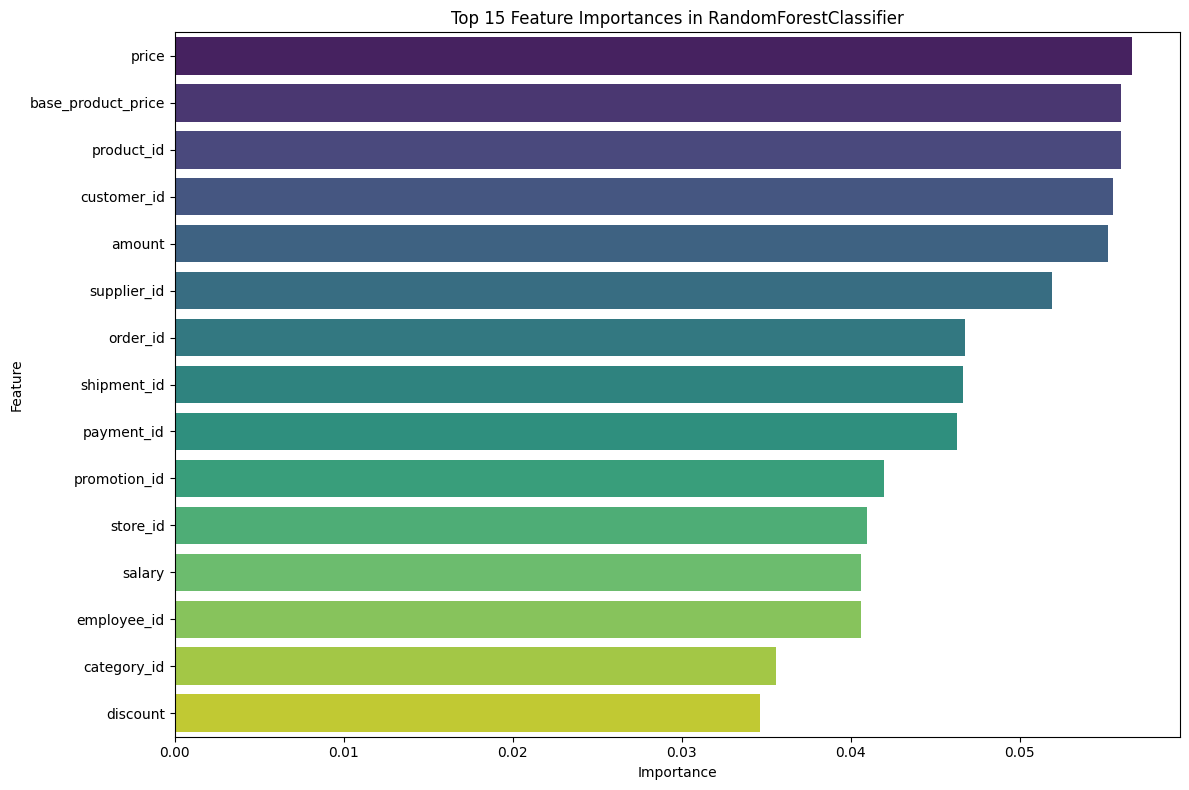

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a Pandas Series for better handling and sorting
features_df = pd.Series(feature_importances, index=X.columns)

# Sort features by importance in descending order and select top N (e.g., top 15)
top_features = features_df.nlargest(15)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Feature Importances in RandomForestClassifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Random Forest Model Diagram (Conceptual Explanation)

A Random Forest is an ensemble machine learning model that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.



### Visualizing a Single Decision Tree from the Random Forest

To illustrate the structure of the Random Forest, let's visualize one of the decision trees within our trained `RandomForestClassifier`. This will show how a single tree makes decisions based on the features.

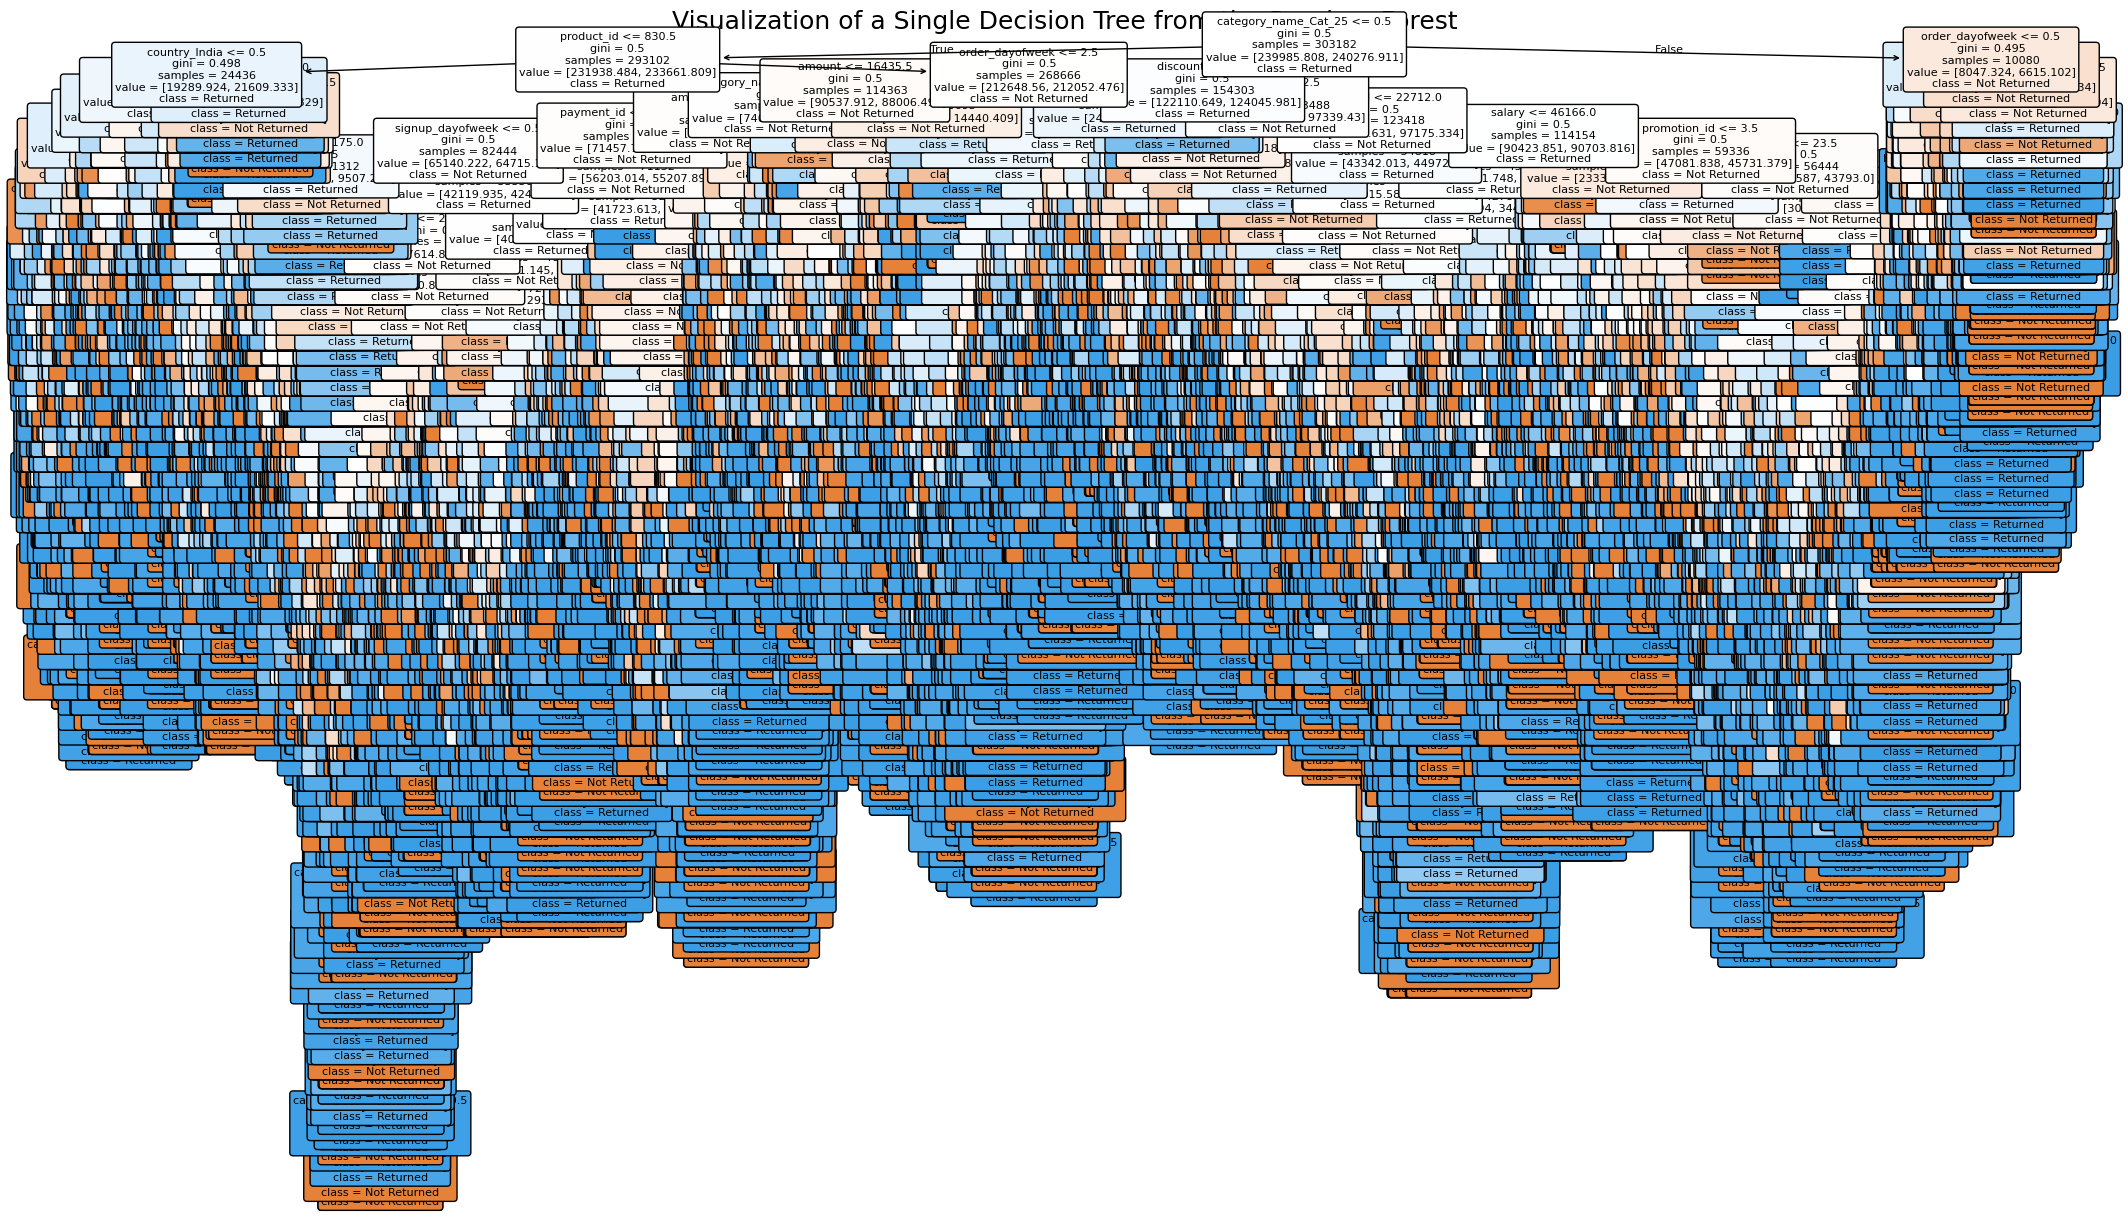

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select one tree from the forest (e.g., the first tree)
one_tree = model.estimators_[0]

plt.figure(figsize=(25, 15))
plot_tree(one_tree,
          feature_names=X.columns.tolist(),  # Use actual feature names
          class_names=['Not Returned', 'Returned'], # Use actual class names
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Visualization of a Single Decision Tree from the Random Forest', fontsize=18)
plt.show()
